In [ ]:
from datasets import load_dataset
from datasets import Dataset
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print as pprint
import numpy as np
import pandas as pd
import random
import re
# from parlai.utils.safety import OffensiveLanguageClassifier
# from rouge_score import rouge_scorer
# import evaluate

# Data

In [2]:
ds = load_dataset("google/boolq", cache_dir='/data/takis/datasets/hf_hub')['train']

In [6]:
prompts = []

for i, row in tqdm(enumerate(ds), total=len(ds)):
    prompts.append('passage: %s, question: %s, answer: %s' %(row['passage'], row['question'], row['answer']))
prompts = np.array(prompts)

keep_idx = random.sample(list(range(len(prompts))), 600)
prompts = prompts[keep_idx]

100%|██████████| 9427/9427 [00:00<00:00, 67970.69it/s]


# Model

In [7]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '0'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [8]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models')
model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)
model = model.eval()

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  5.23it/s]


# Hidden states

In [9]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    hooks.append(layer.self_attn.register_forward_hook(get_activation(i)))

In [10]:
hidden_states = []
activations = {}

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.no_grad():
        inputs = tokenizer(p, return_tensors="pt").input_ids
        outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 356: 100%|██████████| 600/600 [00:32<00:00, 18.67it/s] 


## Attractors

In [11]:
target_layers = [i for i in range(len(model.model.layers))]
all_prompts_attractors = hidden_states

### Different prompts t-sne

In [13]:
ic_prompts = ["Write a short factual passage about a real-world topic, followed by a true-or-false question directly based on a detail in the passage. Provide the answer as 'true' or 'false'.",
           "Generate a passage that implies something not explicitly stated. Then create a true-or-false question that requires inference from the passage, and provide the answer.",
           "Invent a passage about a historical or scientific topic, then write a question that contains a subtle factual error. Answer with 'true' or 'false' accordingly.",
           "Create a short informative passage, then generate a question that paraphrases part of it but introduces a slight inaccuracy. Provide the true/false answer.",
           "Write a passage involving contrasting facts or events. Then ask a true-or-false question using negation (e.g., 'did not', 'never'), and answer it.",
           "Generate a passage involving cause-and-effect or events in time. Then write a true-or-false question that tests understanding of that structure, and give the answer.",
           "Write a passage that sounds plausible. Then ask a question that seems likely but is actually false given the passage. Provide the correct answer.",
           "Produce a passage that could be misinterpreted, then pose a true-or-false question that tests precise understanding. Provide the correct answer.",
           "Create a passage that blends general world knowledge with specific details. Then write a true-or-false question grounded only in the passage, and answer it.",
           "Write a passage on a narrow topic. Then ask a question that seems related but is not supported by the passage. Provide 'false' as the answer."]

In [14]:
hidden_states = []
activations = {}

pbar = tqdm(enumerate(prompts[:10]), total=len(prompts[:10]))
for i, p in pbar:

    for icp in ic_prompts:

        pbar.set_description('cur prompt length (chars): %d' %(len(p)))
        
        with torch.no_grad():
            inputs = tokenizer(p + '\n' + icp, return_tensors="pt").input_ids
            outputs = model.forward(inputs.to(device))
            
        for k in activations.keys():
            activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
            activations[k] =  torch.mean(activations[k], dim=-2)


        hidden_states.append(copy.deepcopy(activations))
        activations = {}

cur prompt length (chars): 753: 100%|██████████| 10/10 [00:05<00:00,  1.97it/s]


In [18]:
target_layer = 16

cur_attractors = []
for i in range(len(hidden_states)):
    cur_attractors.append(hidden_states[i][target_layer])
cur_attractors = torch.stack(cur_attractors, dim=0).squeeze()

In [19]:
cur_attractors_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=8, random_state=0).fit_transform(cur_attractors.detach().to(float).cpu().numpy())

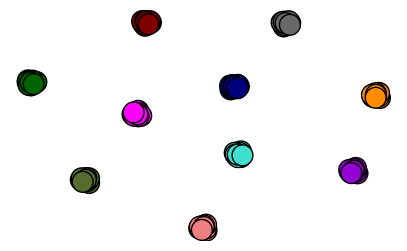

In [20]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (5, 3)

plt.scatter(cur_attractors_emb[:, 0], cur_attractors_emb[:, 1], c=10*['maroon'] + \
                                                                  10*['darkgreen'] + \
                                                                  10*['navy'] + \
                                                                  10*['darkorange'] + \
                                                                  10*['lightcoral'] + \
                                                                  10*['dimgrey'] + \
                                                                  10*['darkolivegreen'] + \
                                                                  10*['turquoise'] + \
                                                                  10*['darkviolet'] + \
                                                                  10*['magenta'], edgecolor='black')
plt.xticks([])
plt.yticks([])
plt.show()

# Behavior steering

In [21]:
for hook in hooks:
    hook.remove()

In [23]:
target_layer = 16


def add_noise(target_layer):
    def hook(model, input, output):
        if (abs(strength) > 1e-5):
            output = (output[0] + strength*noise.to(device), *output[1:])
        return output
    return hook


hook = model.model.layers[target_layer].self_attn.register_forward_hook(add_noise(target_layer))

In [24]:
target_prompt = 4

prompt = '''\n Now generate 3 different passages, questions, and answers similar to the example above. Please make sure each question you generate has a boolean answer that can be answered by the passage. Make sure each passage and question is different and sufficiently rephrased. Please make sure you generate passages, questions and both true and false answers.'''

In [24]:
pprint (prompts[target_prompt])

passage: Casting for series one began in early 2009 in Brisbane, Melbourne and Sydney. All cast members had to be 
skilled in drama and dancing and had to cope with Australia's best choreographers. Filming began on 13 July 2009 
and wrapped up in early November. The series premiere was originally planned for a mid-2010 premiere on ABC3, 
however, like Dead Gorgeous, the premiere was pushed to ABC1 on 31 May 2010 and ABC3 on 6 June 2010. The first 
series premiered on Germany's ZDF on 26 September 2010., question: are the dancers on dance academy real dancers, 
answer: True

## No steering

In [28]:
strength = 0
noise = 0 

responses = []

aug_prompt = prompts[target_prompt] + '\n' + prompt

print ('No steering...')


with torch.no_grad():
    inputs = tokenizer(aug_prompt, return_tensors="pt").input_ids
    outputs = model.generate(inputs.to(device), max_new_tokens=500, do_sample=True, top_k=50, top_p=0.95, temperature=0.6, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
responses.append(output_text := tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0])

pprint (output_text)
    

print ('\n\n------------------------------------------------\n\n')
print ('Steering...')

denom = 20 
strength = 1


noise = torch.randn(all_prompts_attractors[target_prompt][target_layer].shape).to(torch.bfloat16)/denom



with torch.no_grad():
    inputs = tokenizer(aug_prompt, return_tensors="pt").input_ids
    outputs = model.generate(inputs.to(device), max_new_tokens=500, do_sample=True, top_k=20, top_p=0.95, temperature=0.2, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
responses.append(output_text := tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0])

pprint (output_text)
            
        

No steering...


passage: In computer science, a stack is a linear data structure that follows the LIFO (last in, first out) 
principle. It can be implemented using arrays, linked lists, or other data structures. Stacks are used in many 
applications, including parsing expressions, evaluating postfix notation, and implementing recursive algorithms. 
They are also used in recursive data structures such as trees and graphs., question: are stacks implemented using 
linked lists?, answer: True

passage: In computer networks, a router is a device that connects multiple networks together and routes traffic 
between them. It uses IP addresses to forward packets of data to their destination. Routers can be used to connect 
local area networks (LANs) to wide area networks (WANs) or to the internet. They are typically used in large 
networks, such as those used in businesses and governments., question: do routers connect local area networks to 
the internet?, answer: False

passage: In programming, a while loop is a control structure that allows a program to repeat a set of instructions 
as long as a certain condition is true. The loop continues to execute until the condition is false. While loops are
commonly used in algorithms and are a fundamental part of many programming languages. They are often used in 
conjunction with conditional statements to control the flow of a program., question: do while loops repeat 
instructions until a condition is false?, answer: True

passage: In computer science, a binary search tree is a data structure that consists of nodes with keys and values.
Each node has a value and a key, and it has at most two children, a left child and a right child. The keys in the 
left subtree are less than the key in the node, and the keys in the right subtree are greater than the key in the 
node. This property makes binary search trees efficient for searching and inserting data., question: do binary 
search trees have at least one child?, answer: False

passage: In software development, an interface is a contract that specifies a set of methods that must be 
implemented by any class that implements it. Interfaces are used to define a common set of methods that can be used
by different classes, making it easier to write code that can work with different classes. They are often used in 
object-oriented programming languages such as Java and C#. Interfaces can also be used to define a set of methods 
that can be used by multiple classes., question: can interfaces be used to define a set of methods that can



------------------------------------------------


Steering...


Passage 1:
In computing, a database is a collection of organized data that is stored in a way that facilitates efficient 
retrieval and manipulation. A database is a structured collection of data that is stored in a way that allows for 
efficient searching, sorting, and retrieval of data. A database is a collection of data that is organized in a way 
that allows for efficient querying and retrieval of data.

Question 1:
Is a database a collection of organized data?
Answer: True

Passage 2:
A stack is a linear data structure that follows the Last-In-First-Out (LIFO) principle. A stack is a data structure
that allows elements to be added and removed from the top of the stack. A stack is a linear data structure that 
follows the LIFO principle, where the last element added to the stack is the first one to be removed.

Question 2:
Is a stack a linear data structure?
Answer: True

Passage 3:
A binary search tree is a data structure in which each node has a comparable value. A binary search tree is a data 
structure that is used to store a collection of items in a way that allows for efficient searching and retrieval of
items. A binary search tree is a data structure that is used to store a collection of items in a way that allows 
for efficient searching and retrieval of items.

Question 3:
Is a binary search tree a data structure that is used to store a collection of items?
Answer: True

Passage 4:
A queue is a linear data structure that follows the First-In-First-Out (FIFO) principle. A queue is a data 
structure that allows elements to be added to the end of the queue and removed from the front of the queue. A queue
is a data structure that follows the FIFO principle, where the first element added to the queue is the first one to
be removed.

Question 4:
Is a queue a data structure that follows the FIFO principle?
Answer: True

Passage 5:
A graph is a non-linear data structure that consists of nodes or vertices connected by edges. A graph is a data 
structure that allows for efficient searching and retrieval of nodes and edges. A graph is a non-linear data 
structure that consists of nodes or vertices connected by edges.

Question 5:
Is a graph a non-linear data structure?
Answer: True

Passage 6:
A linked list is a linear data structure that consists of a sequence of nodes, each of which contains